# Financial News - Preprocessing for word2vec

See notebook [lda_financial_news](../15_topic_modeling/07_financial_news/lda_financial_news.ipynb) for download instructions.

## Imports

In [1]:
import os, tarfile, sys, json
from pathlib import Path
from time import time
from pprint import pprint
from collections import Counter

import numpy as np
from numpy.random import choice
import pandas as pd
import seaborn as sns

import spacy
from spacy.lang.en import English

from gensim.models.word2vec import LineSentence
from gensim.models.phrases import Phrases, Phraser

### Settings

In [2]:
pd.set_option('float_format', '{:,.2f}'.format)
sns.set_style('white')
np.random.seed(42)

In [3]:
def format_time(t):
    m, s = divmod(t, 60)
    h, m = divmod(m, 60)
    return '{:02.0f}:{:02.0f}:{:02.0f}'.format(h, m, s)

In [6]:
stop_words = set(pd.read_csv('http://ir.dcs.gla.ac.uk/resources/linguistic_utils/stop_words',
                             header=None,
                             ).squeeze().tolist())

### Paths

In [7]:
data_path = Path('..', 'data', 'us-financial-news')

In [8]:
results_path = Path('results', 'financial_news')
if not results_path.exists():
    results_path.mkdir(exist_ok=True)

In [9]:
article_path = results_path / 'articles.txt'
clean_article_path = results_path / 'articles_clean.txt'

## Load Data

In [10]:
section_titles = ['Press Releases - CNBC',
                  'Reuters: Company News',
                  'Reuters: World News',
                  'Reuters: Business News',
                  'Reuters: Financial Services and Real Estate',
                  'Top News and Analysis (pro)',
                  'Reuters: Top News',
                  'The Wall Street Journal &amp; Breaking News, Business, Financial and Economic News, World News and Video',
                  'Business &amp; Financial News, U.S &amp; International Breaking News | Reuters',
                  'Reuters: Money News', 'Reuters: Technology News']

In [11]:
articles = []
counter = Counter()
start = time()
for f in data_path.glob('*/**/*.json'):
    article = json.load(f.open())
    if article['thread']['section_title'] in set(section_titles):
        text = article['text'].lower().split()
        counter.update(text)
        articles.append(' '.join([t for t in text if t not in stop_words]))

print(f'Done loading {len(articles):,.0f} articles in {format_time(time()-start)}')

Done loading 125,964 articles in 01:14:37


In [12]:
article_path.write_text('\n'.join(articles))

418422851

## Clean Financial News Articles

In [13]:
articles = article_path.read_text().split('\n')
len(articles)

125964

### Sentence Boundary Detection

In [14]:
def clean_doc(d):
    doc = []
    for sent in d.sents:
        s = [t.text.lower() for t in sent if not
        any([t.is_digit, not t.is_alpha, t.is_punct, t.is_space])]
        if len(s) > 5 or len(sent) < 100:
            doc.append(' '.join(s))
    return doc

In [17]:
nlp = English()
nlp.add_pipe('sentencizer');

In [18]:
clean_articles = []
iter_articles = (article for article in articles)
for i, doc in enumerate(nlp.pipe(iter_articles, batch_size=100, n_process=8), 1):
    if i % int(len(articles) / 100) + 1 == 0:
        print(f'{i / len(articles):.1%}', end=' ', flush=True)
    clean_articles.extend(clean_doc(doc))

In [19]:
clean_article_path.write_text('\n'.join(clean_articles))

356895840

### Corpus Stats

In [20]:
len(clean_articles)

2982031

In [21]:
vocab = Counter()
sent_length = []
for sentence in clean_articles:
    tokens = sentence.lower().split()
    sent_length.append(len(tokens))
    vocab.update(tokens)

In [22]:
len(sent_length)

2982031

In [23]:
pd.Series(sent_length).describe(percentiles=np.arange(.1, 1, .1).round(1))

count   2,982,031.00
mean           15.40
std            20.75
min             0.00
10%             4.00
20%             6.00
30%             8.00
40%            10.00
50%            12.00
60%            14.00
70%            17.00
80%            20.00
90%            25.00
max         6,910.00
dtype: float64

In [24]:
most_common = (pd.DataFrame(vocab.most_common(), columns=['token', 'count'])
               .pipe(lambda x: x[~x.token.str.lower().isin(stop_words)]))

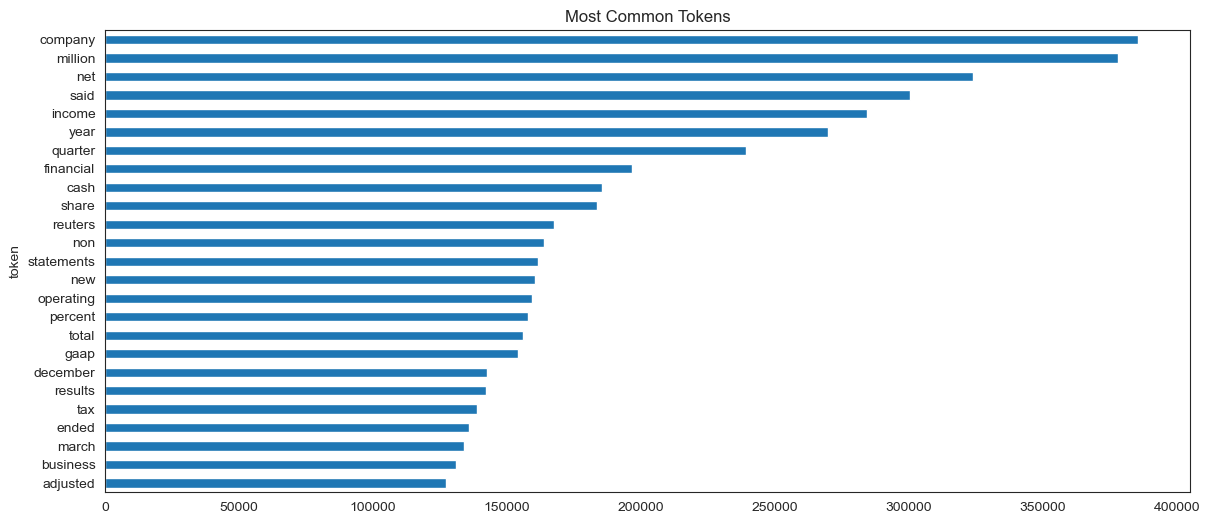

In [25]:
most_common.head(25).set_index('token')['count'].sort_values().plot.barh(title='Most Common Tokens', figsize=(14, 6));

### Inspect Result

In [26]:
clean_articles[:3]

['hours ago emerging markets soared percent todd gordon says rally wo stop',
 'big rally emerging markets tracked emerging market etf eem weak dollar',
 'given gordon sees inverse relationship eem dollar measured charts dollar tracking etf uup believes']

## Create n-grams

In [27]:
max_length = 3

In [42]:
n_grams = pd.DataFrame()
start = time()
sentences = LineSentence(clean_article_path.as_posix())
for n in range(2, max_length + 1):
    print(n, end=' ')
    if n>2:
        sentences = LineSentence((results_path / f'articles_{n-1}_grams.txt').as_posix())
    phrases = Phrases(sentences, threshold=100, min_count=10)

    s = pd.Series(phrases.export_phrases()) 
    s = s.to_frame('score').reset_index().rename(
        columns={'index': 'phrase'}).assign(length=n)

    n_grams = pd.concat([n_grams, s])
    grams = Phraser(phrases)
    sentences = grams[sentences]

    with (results_path / f'articles_{n}_grams.txt').open('w') as f:
        for sentence in sentences:
            f.write(' '.join(sentence) + '\n')

n_grams = n_grams.sort_values('score', ascending=False)
n_grams.phrase = n_grams.phrase.str.replace('_', ' ')
n_grams['ngram'] = n_grams.phrase.str.replace(' ', '_')

print('\n\tDuration: ', format_time(time() - start))
print(f'\tngrams: {len(n_grams):,d}\n')
print(n_grams.groupby('length').size())

2 3 
	Duration:  00:04:11
	ngrams: 66,468

length
2    29501
3    36967
dtype: int64


In [45]:
n_grams.groupby('length').apply(lambda x: x.nlargest(10, 'score') , include_groups=False)

phrase            score  \
length                                                      
2      24827          bruckhaus deringer       182,440.40   
       12365       pracha hariraksapitak       182,440.40   
       19269               citigate dewe       182,440.40   
       25805  mukhammadsharif mamatkulov       182,440.40   
       13976    hidradenitis suppurativa       182,440.40   
       29232                nidaa tounes       182,026.70   
       27458            navesh chitrakar       182,026.70   
       24385      axalimogene filolisbac       182,026.70   
       21537             koustav samanta       182,026.70   
       27908     munkhchimeg davaasharav       181,935.02   
3      73                   kuala lumpur 1,395,223,390.50   
       7847              sanjana shivdas   719,870,860.00   
       4112              marguerita choy   422,450,531.00   
       94            petroleo brasileiro   358,672,498.67   
       20970            aeterna zentaris   333,413,872.00   
       6613                   dado ruvic   308,349,542.46   
       14040                kaori kaneko   231,116,434.00   
       5463           abhinav ramnarayan   229,222,037.00   
       5822                 fathin ungku   214,066,861.00   
       9966                 leika kihara   209,330,868.50   

                                   ngram  
length                                    
2      24827          bruckhaus_deringer  
       12365       pracha_hariraksapitak  
       19269               citigate_dewe  
       25805  mukhammadsharif_mamatkulov  
       13976    hidradenitis_suppurativa  
       29232                nidaa_tounes  
       27458            navesh_chitrakar  
       24385      axalimogene_filolisbac  
       21537             koustav_samanta  
       27908     munkhchimeg_davaasharav  
3      73                   kuala_lumpur  
       7847              sanjana_shivdas  
       4112              marguerita_choy  
       94            petroleo_brasileiro  
       20970            aeterna_zentaris  
       6613                   dado_ruvic  
       14040                kaori_kaneko  
       5463           abhinav_ramnarayan  
       5822                 fathin_ungku  
       9966                 leika_kihara